# Met data starter code

The following packages are required and can be installed using any package manager (e.g., Conda, pip).  An `environment.yml` file is also provided in the main repo.

In [145]:
# !pip install matplotlib
# !pip install pandas

In [146]:
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

To read the data, we'll use Pandas (`pd`), a popular package for working with table-like data (think Excel, but Python).  The following code assumes the data have been copied from the UW Atmospheric Sciences website and converted to plain text (.txt).  This can be done as follows:

1. Navigate to https://atmos.washington.edu/cgi-bin/list_uw.cgi, choose a day, and click "Data".
2. Select **all** of the text (`Cmd + A` on Mac or `Ctrl + A` on Windows).  This includes the header with the date.
3. Paste the text into an editor and save it as plain text (`.txt` extension)
   - On Mac: Open TextEdit. By default, TextEdit creates Rich-Text Format files (.rtf). To create plain-text, click `Format > Make Plain Text` before saving the file as a `.txt`.
   - On Windows: Open Notepad. Plain text should be the default.
  
If you are new to Pandas, you can read this introduction here: https://pandas.pydata.org/docs/user_guide/10min.html

First, update the variable `MET_DATA_PATH` with the path to your data.
Then read the data using the `read_csv` function. Providing `r'\s+'` for the `sep` keyword argument indicates the data are delimited by a variable number of spaces.
The argument `skiprows=[0, 1, 2, 4, 5]` tells Pandas to skip these rows, which contain header information or blank lines (Note: lines are counted from 0).

This procedure omits units.  Refer to the original file for this information.

In [147]:
MET_DATA_PATH = 'C:\\Users\\Alex Eagan\\Documents\\GitHub\\CEWA590-starter-codes\\met\\ATG rooftop data for 2 April 2026.txt'  #TODO: your path here

met_data = pd.read_csv(MET_DATA_PATH,
                       sep=r'\s+',
                       skiprows=[0, 1, 2, 4])

# Writing a variable name on the last line of a notebook cell will print
# it to the workspace:
met_data

,Time,RHum,Temp,Direct,Speed,Gust,Rain,Radiation,Pres
0,00:00:40,97,48,64,5,7,0.0,64.97,995.9
1,00:01:40,96,48,67,5,7,0.0,61.58,995.9
2,00:02:40,96,48,92,6,7,0.0,58.91,995.9
3,00:03:40,97,48,105,8,10,0.0,60.62,996.0
4,00:04:40,96,48,91,8,9,0.0,62.47,996.0
...,...,...,...,...,...,...,...,...,...
1436,23:55:40,61,53,214,12,18,0.0,110.15,1020.7
1437,23:56:40,61,0,200,13,0,0.0,0.00,NaN
1438,23:57:40,61,0,202,12,0,0.0,0.00,1020.7
1439,23:58:40,61,53,195,11,13,0.0,128.43,1020.7


The `time` column is read in as a string, which is not very useful for our purposes.  Instead, we'll convert it to a Pandas Timedelta which represents a duration. For plotting, we'll' convert each duration to an integer representing seconds measured from the start of the day.

**Note**: seconds are a relative measure of time.  When processing geophysical data, we often need to associate measurements with a specific day and time (often called a datetime).  Additional code at the end of this notebook outlines a procedure for converting the time column to datetimes, which enable us to use Pandas' date and time functionality.

If you are new to Pandas, new variables are assigned to the DataFrame using `met_data['new_variable_name] = ...`.  The index of the DataFrame is used to label and order the rows.  The index is accessed using `met_data.index`.


In [148]:
# Convert time to a timedelta and set it as the index.
met_data['Timedelta'] = pd.to_timedelta(met_data['Time'])
met_data = met_data.set_index(['Timedelta'])

# Extract the seconds (from 00:00:00 UTC).
met_data['Seconds'] = met_data.index.seconds

met_data

,Time,RHum,Temp,Direct,Speed,Gust,Rain,Radiation,Pres,Seconds
Timedelta,,,,,,,,,,
0 days 00:00:40,00:00:40,97,48,64,5,7,0.0,64.97,995.9,40
0 days 00:01:40,00:01:40,96,48,67,5,7,0.0,61.58,995.9,100
0 days 00:02:40,00:02:40,96,48,92,6,7,0.0,58.91,995.9,160
0 days 00:03:40,00:03:40,97,48,105,8,10,0.0,60.62,996.0,220
0 days 00:04:40,00:04:40,96,48,91,8,9,0.0,62.47,996.0,280
...,...,...,...,...,...,...,...,...,...,...
0 days 23:55:40,23:55:40,61,53,214,12,18,0.0,110.15,1020.7,86140
0 days 23:56:40,23:56:40,61,0,200,13,0,0.0,0.00,NaN,86200
0 days 23:57:40,23:57:40,61,0,202,12,0,0.0,0.00,1020.7,86260


Now we can plot the data.  Variables are accessed using brackets with the variable name as a string, `met_data['variable_name']`.  This example uses matplotlib, but you are free to use whatever plotting package you'd like.

Text(0, 0.5, 'Wind speed (knot)')

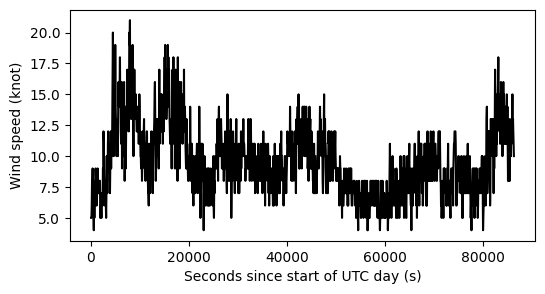

In [149]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data['Seconds'], met_data['Speed'], color='k')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Wind speed (knot)')  # units from .txt file
# fig.savefig('wind_speed_plot.png', dpi=200)  # uncomment to save

Or, as a scatter plot (line plots can be misleading, since gaps in data are connected).

Text(0, 0.5, 'Wind speed (knot)')

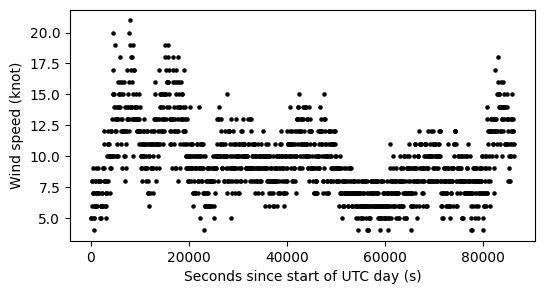

In [150]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(met_data['Seconds'], met_data['Speed'], color='k', s=5)
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Wind speed (knot)')
# fig.savefig('wind_speed_scatter.png', dpi=200)  # uncomment to save

Pandas DataFrames can be sliced using their index. There are also many functions which can be accessed in the form of DataFrame methods. For example, if we wanted the median wind speed between hours 2 and 3:

In [151]:
start_time = pd.Timedelta(2, 'h')
end_time = pd.Timedelta(3, 'h')
met_data[start_time:end_time]['Speed'].median()

np.float64(13.0)

Pandas also includes powerful functions such as [groupby operations](https://pandas.pydata.org/docs/user_guide/groupby.html).  For example, to group by hour and take the mean (or median):

In [152]:
# Drop the 'Time' column, which is not numerical.  Since we want to compute
# statistics within each hour, we'll round down to the nearest hour (floor).
met_data_hourly = met_data.drop('Time', axis=1).groupby(met_data.index.floor('h')).mean()  # try median?

met_data_hourly

,RHum,Temp,Direct,Speed,Gust,Rain,Radiation,Pres,Seconds
Timedelta,,,,,,,,,
0 days 00:00:00,95.100000,48.383333,100.500000,7.366667,9.200000,0.000000,64.846333,996.086207,1810.000000
0 days 01:00:00,86.316667,47.750000,168.083333,12.550000,15.700000,0.000167,64.766667,996.694915,5410.000000
0 days 02:00:00,82.233333,47.416667,192.366667,13.516667,16.950000,0.000000,16.846667,997.698333,9010.000000
0 days 03:00:00,84.933333,47.000000,176.900000,10.933333,13.416667,0.000000,0.001000,998.691667,12610.000000
0 days 04:00:00,80.316667,45.200000,192.133333,13.950000,17.616667,0.000167,0.000000,999.917241,16210.000000
0 days 05:00:00,79.333333,45.816667,162.250000,10.650000,13.666667,0.000000,0.000000,1000.884211,19810.000000
0 days 06:00:00,81.683333,45.433333,141.933333,8.133333,10.400000,0.000000,0.000000,1001.911864,23410.000000
0 days 07:00:00,80.800000,45.633333,157.033333,10.083333,12.583333,0.000000,0.000000,1002.763793,27010.000000
0 days 08:00:00,79.116667,42.066667,165.066667,9.833333,11.950000,0.000000,0.000000,1003.667241,30610.000000


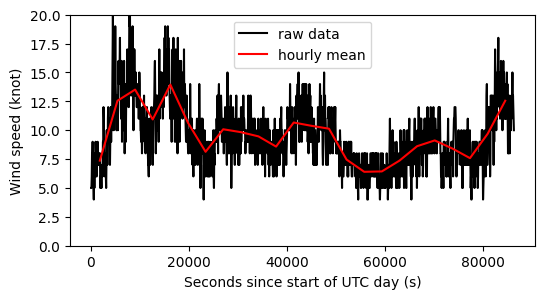

In [153]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data['Seconds'], met_data['Speed'], color='k', label='raw data')
ax.plot(met_data_hourly['Seconds'], met_data_hourly['Speed'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Wind speed (knot)')
ax.set_ylim([0, 20])
ax.legend()
# fig.savefig('wind_speed_hourly_means.png', dpi=200)  # uncomment to save

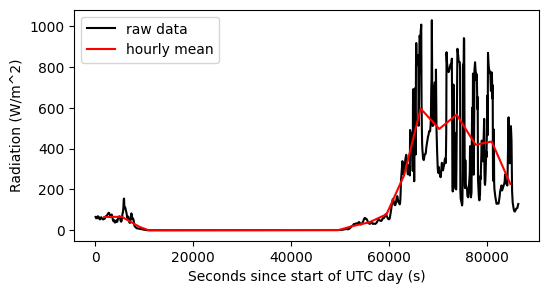

In [154]:
met_data_rad = met_data[met_data['Radiation'] != 0]  # filter out zero values, which are likely bad data
met_data_hourly_rad = met_data_rad.drop('Time', axis=1).groupby(met_data_rad.index.floor('h')).mean()  # try median?
#Filtering out zero values is a common data cleaning step, especially when zero is not a physically meaningful value for the variable in question

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data_rad['Seconds'], met_data_rad['Radiation'], color='k', label='raw data')
ax.plot(met_data_hourly_rad['Seconds'], met_data_hourly_rad['Radiation'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Radiation (W/m^2)')
#ax.set_ylim([0, 100])
ax.legend()

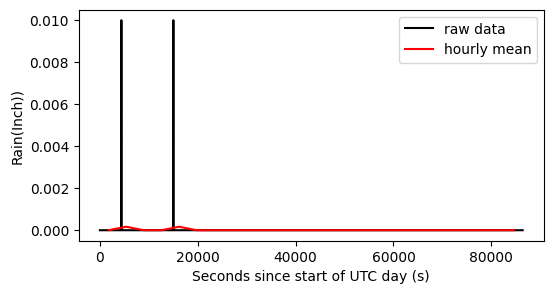

In [155]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data['Seconds'], met_data['Rain'], color='k', label='raw data')
ax.plot(met_data_hourly['Seconds'], met_data_hourly['Rain'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Rain(Inch))')
#ax.set_ylim([0, 100])
ax.legend()

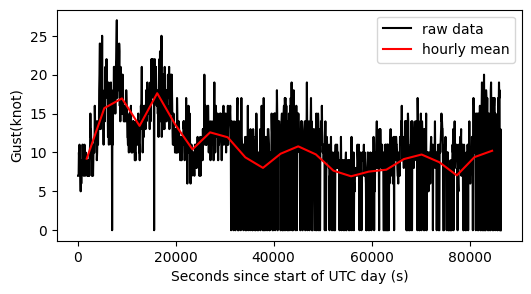

In [156]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data['Seconds'], met_data['Gust'], color='k', label='raw data')
ax.plot(met_data_hourly['Seconds'], met_data_hourly['Gust'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Gust(knot)')
#ax.set_ylim([0, 100])
ax.legend()

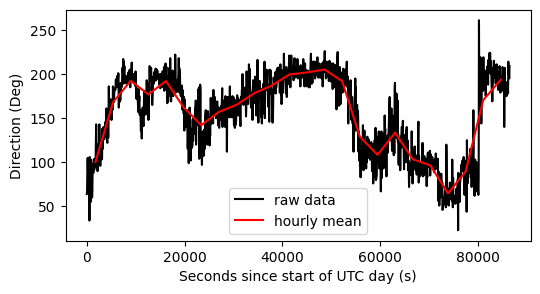

In [157]:
#Was wary here about the direction crossing 0/360 but for today it did not do so.
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data['Seconds'], met_data['Direct'], color='k', label='raw data')
ax.plot(met_data_hourly['Seconds'], met_data_hourly['Direct'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Direction (Deg)')
#ax.set_ylim([0, 100])
ax.legend()

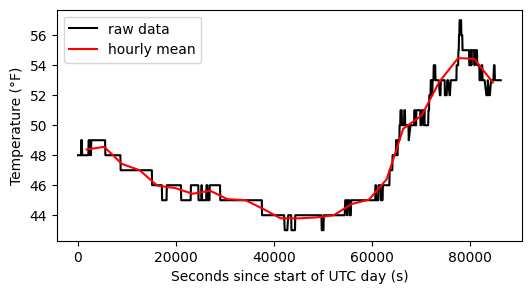

In [158]:
met_data_temp = met_data[met_data['Temp'] != 0]  # filter out zero values, which are likely bad data
met_data_hourly_temp = met_data_temp.drop('Time', axis=1).groupby(met_data_temp.index.floor('h')).mean()  # try median?
#Filtering out zero values is a common data cleaning step, especially when zero is not a physically meaningful value for the variable in question

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data_temp['Seconds'], met_data_temp['Temp'], color='k', label='raw data')
ax.plot(met_data_hourly_temp['Seconds'], met_data_hourly_temp['Temp'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Temperature (°F)')
#ax.set_ylim([0, 30])
ax.legend()

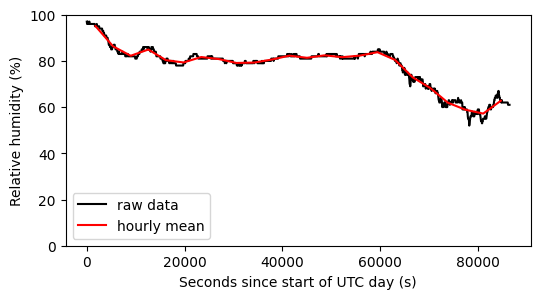

In [159]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data['Seconds'], met_data['RHum'], color='k', label='raw data')
ax.plot(met_data_hourly['Seconds'], met_data_hourly['RHum'], color='r', label='hourly mean')
ax.set_xlabel('Seconds since start of UTC day (s)')
ax.set_ylabel('Relative humidity (%)')
ax.set_ylim([0, 100])
ax.legend()

Math using DataFrames is easy:

In [160]:
met_data['Temp_K'] = (met_data['Temp'] - 32) * 5/9 + 273.15

met_data

,Time,RHum,Temp,Direct,Speed,Gust,Rain,Radiation,Pres,Seconds,Temp_K
Timedelta,,,,,,,,,,,
0 days 00:00:40,00:00:40,97,48,64,5,7,0.0,64.97,995.9,40,282.038889
0 days 00:01:40,00:01:40,96,48,67,5,7,0.0,61.58,995.9,100,282.038889
0 days 00:02:40,00:02:40,96,48,92,6,7,0.0,58.91,995.9,160,282.038889
0 days 00:03:40,00:03:40,97,48,105,8,10,0.0,60.62,996.0,220,282.038889
0 days 00:04:40,00:04:40,96,48,91,8,9,0.0,62.47,996.0,280,282.038889
...,...,...,...,...,...,...,...,...,...,...,...
0 days 23:55:40,23:55:40,61,53,214,12,18,0.0,110.15,1020.7,86140,284.816667
0 days 23:56:40,23:56:40,61,0,200,13,0,0.0,0.00,NaN,86200,255.372222
0 days 23:57:40,23:57:40,61,0,202,12,0,0.0,0.00,1020.7,86260,255.372222


But if you get sick of them, they can easily become normal Numpy arrays using `met_data.values`:

In [161]:
temp_fahrenheit = met_data['Temp'].values
temp_kelvin = (temp_fahrenheit - 32) * 5/9 + 273.15

temp_kelvin

array([282.03888889, 282.03888889, 282.03888889, ..., 255.37222222,
       284.81666667, 255.37222222], shape=(1441,))

# Additional Code

This section provides code for working with the met data in absolute time (datetimes) which will allow us to use the date/time functionality of Pandas. To do this, we need to get the date from the original file and combine it with the `Time` column to create useable Datetimes.  **It is not necessary to use this code for the assignment.**

Below is a function to extract the date from the original `.txt` file.  You could enter the date yourself, but what if you were analyzing a year's worth of data?

If you have followed the steps above when downloading the data, this should work fine.  If the function is unable to extract the date, it returns today's date to prevent things from breaking.

In [162]:
def get_met_data_date(path: str) -> str:
    """
    Get date from a txt file containg met data from the UW Atmospheric Sciences
    roof top station.  Expects date to be in the first line of the file with
    the format dd Month yyyy ("%d %B %Y"), as output on the website
    (e.g., 25 March 2024).

    Note: if no date is found, today's date is returned.

    Args:
        path (str): File path to the met data.

    Returns:
        str: Data collection date in dd Month yyyy format.
    """
    # Get the first line of the file (header) which should contain the date.
    with open(path) as file:
        first_line = file.readline()

    # Use a regular expression (regex) to search for the date pattern.  Regex
    # is a powerful tool for extracting data via pattern matching:
    # https://developers.google.com/edu/python/regular-expressions
    match = re.search(r'\d+\s[A-Za-z]+\s\d+', first_line)

    # If there is a match, return it.  Otherwise, use today's date.
    if match:
        date_str = match.group()
    else:
        date_str = pd.Timestamp.today(tz='UTC').strftime("%d %B %Y")
        print("Unable to extract date from file. Returning today's date.")

    return date_str

Here we use the function to create a column, `Datetime`, and assign it as the index.

In [163]:
met_data['Date'] = get_met_data_date(MET_DATA_PATH)
met_data['Datetime'] = pd.to_datetime(met_data['Date'] + ' ' + met_data['Time'], utc=True)
met_data = met_data.set_index('Datetime')

met_data

,Time,RHum,Temp,Direct,Speed,Gust,Rain,Radiation,Pres,Seconds,Temp_K,Date
Datetime,,,,,,,,,,,,
2026-04-02 00:00:40+00:00,00:00:40,97,48,64,5,7,0.0,64.97,995.9,40,282.038889,2 April 2026
2026-04-02 00:01:40+00:00,00:01:40,96,48,67,5,7,0.0,61.58,995.9,100,282.038889,2 April 2026
2026-04-02 00:02:40+00:00,00:02:40,96,48,92,6,7,0.0,58.91,995.9,160,282.038889,2 April 2026
2026-04-02 00:03:40+00:00,00:03:40,97,48,105,8,10,0.0,60.62,996.0,220,282.038889,2 April 2026
2026-04-02 00:04:40+00:00,00:04:40,96,48,91,8,9,0.0,62.47,996.0,280,282.038889,2 April 2026
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02 23:55:40+00:00,23:55:40,61,53,214,12,18,0.0,110.15,1020.7,86140,284.816667,2 April 2026
2026-04-02 23:56:40+00:00,23:56:40,61,0,200,13,0,0.0,0.00,NaN,86200,255.372222,2 April 2026
2026-04-02 23:57:40+00:00,23:57:40,61,0,202,12,0,0.0,0.00,1020.7,86260,255.372222,2 April 2026


By using a Pandas DateTimeIndex, we can easily slice the data in time:

In [164]:
start_time = pd.Timestamp('03-25-2024 02:00:00Z')
end_time = pd.Timestamp('03-25-2024 03:00:00Z')

met_data[start_time:end_time]

,Time,RHum,Temp,Direct,Speed,Gust,Rain,Radiation,Pres,Seconds,Temp_K,Date
Datetime,,,,,,,,,,,,


To access the times, use `met_data.index`:

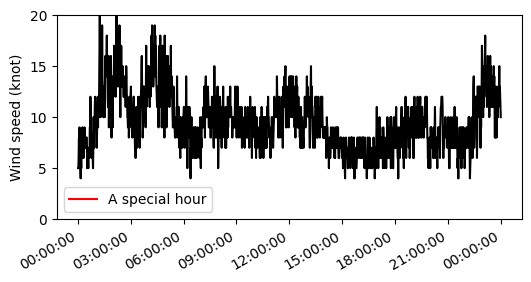

In [165]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data.index, met_data['Speed'], color='k')
ax.plot(met_data[start_time:end_time].index,
        met_data[start_time:end_time]['Speed'],
        color='r',
        label='A special hour')

# Format the dates.  See https://strftime.org/ for formats.
fmt = mpl.dates.DateFormatter('%H:%M:%S')
ax.xaxis.set_major_formatter(fmt)
fig.autofmt_xdate()

ax.set_ylabel('Wind speed (knot)')  # units from .txt file
ax.set_ylim([0, 20])
ax.legend()
# fig.savefig('wind_speed_datetime_plot.png', dpi=200)  # uncomment to save

Grouping by hour (`'h'`) and taking the mean is now easier with the `resample('h')` method:

In [166]:
met_data_hourly = met_data.drop(['Time', 'Date'], axis=1).resample('h').mean()

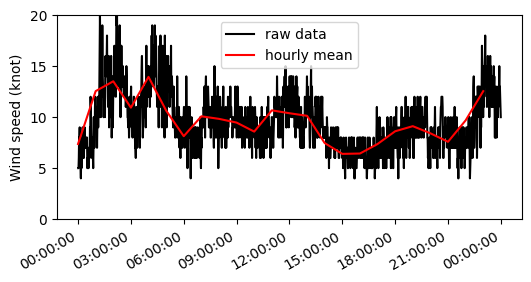

In [167]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(met_data.index, met_data['Speed'], color='k', label='raw data')
ax.plot(met_data_hourly.index, met_data_hourly['Speed'], color='r', label='hourly mean')

# Format the dates.  See https://strftime.org/ for formats.
fmt = mpl.dates.DateFormatter('%H:%M:%S')
ax.xaxis.set_major_formatter(fmt)
fig.autofmt_xdate()

ax.set_ylabel('Wind speed (knot)')  # units from .txt file
ax.set_ylim([0, 20])
ax.legend()
# fig.savefig('wind_speed_datetime_hourly_means.png', dpi=200)  # uncomment to save